# Laboratorio 2
## Problema 1 - Binarización de una imagen

### Objetivo

Implementar una función que permita convertir una imagen a formato binario utilizando un umbral fijo. Para ello se convierte la imagen a escala de grises y posteriormente se aplica una operación de umbralización.

## Fundamento teórico

Una imagen digital está formada por una matriz de píxeles. En una imagen a color, cada píxel contiene tres componentes (Rojo, Verde y Azul). Para realizar una binarización normalmente primero se convierte la imagen a escala de grises, donde cada píxel posee únicamente un nivel de intensidad entre 0 y 255.

Posteriormente se aplica un umbral (Threshold) que permite clasificar cada píxel en uno de dos grupos:

- Intensidad mayor al umbral → Blanco (255)
- Intensidad menor o igual al umbral → Negro (0)

La binarización constituye una de las etapas fundamentales en tareas de segmentación, reconocimiento de objetos y visión por computadora.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración para visualizar imágenes
plt.rcParams["figure.figsize"] = (8,6)

## Carga de la imagen

En esta sección se carga una imagen desde el directorio del proyecto utilizando OpenCV. Debido a que OpenCV almacena las imágenes en formato BGR, se realiza una conversión al espacio RGB para que los colores sean mostrados correctamente con Matplotlib.

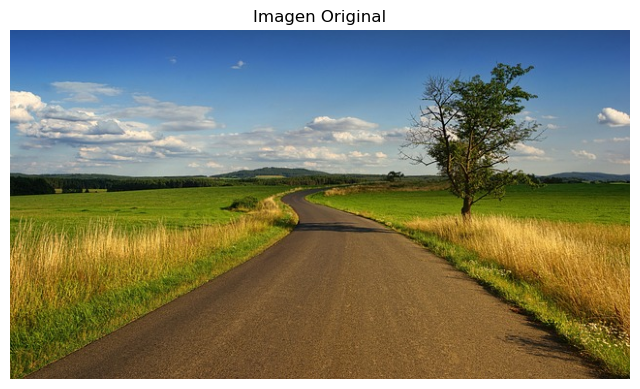

In [12]:
ruta = "../Imagenes lab/1.jpg"

imagen = cv2.imread(ruta)

if imagen is None:
    raise Exception("No fue posible cargar la imagen.")

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.imshow(imagen_rgb)
plt.title("Imagen Original")
plt.axis("off")
plt.show()

## Implementación de la función de binarización

Se implementa una función reutilizable que recibe una imagen y un valor de umbral. La función convierte la imagen a escala de grises y posteriormente aplica una binarización utilizando `cv2.threshold()`.

In [13]:
def binarizar_umbral(imagen, umbral=127):

    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    _, binaria = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )

    return gris, binaria

## Aplicación del método de umbral fijo

Se aplica la función implementada anteriormente utilizando un umbral de 127, valor comúnmente utilizado cuando la iluminación de la imagen es relativamente uniforme.

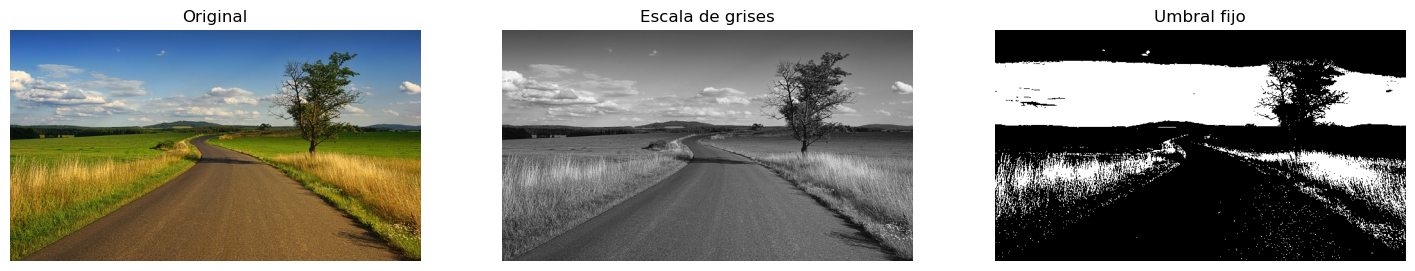

In [14]:
gris, binaria = binarizar_umbral(imagen,127)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(imagen_rgb)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(gris,cmap="gray")
ax[1].set_title("Escala de grises")
ax[1].axis("off")

ax[2].imshow(binaria,cmap="gray")
ax[2].set_title("Umbral fijo")
ax[2].axis("off")

plt.show()

## Binarización automática mediante el método de Otsu

A diferencia del umbral fijo, el método de Otsu calcula automáticamente el valor de umbral que mejor separa los objetos del fondo. Este método resulta especialmente útil cuando no se conoce previamente cuál debería ser el umbral adecuado.

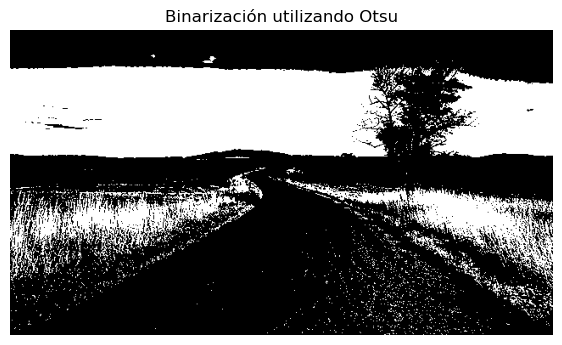

In [15]:
_, otsu = cv2.threshold(
    gris,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(7,6))
plt.imshow(otsu, cmap="gray")
plt.title("Binarización utilizando Otsu")
plt.axis("off")
plt.show()

## Comparación entre ambos métodos

En la siguiente figura se compara el resultado obtenido mediante un umbral fijo y mediante el algoritmo de Otsu.

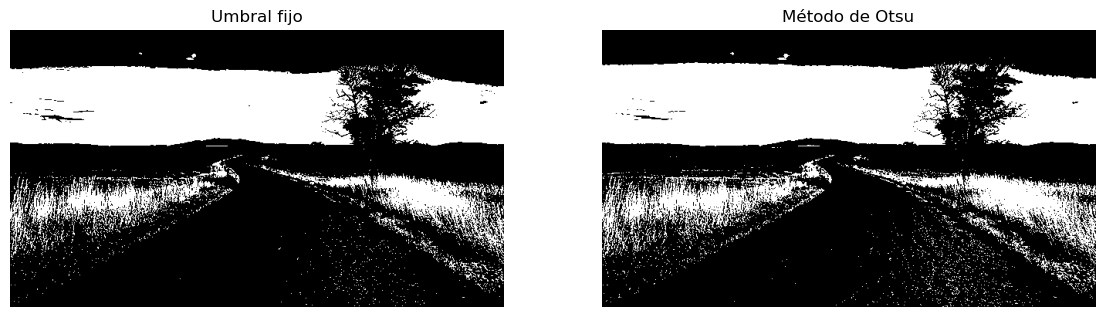

In [16]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(binaria,cmap="gray")
ax[0].set_title("Umbral fijo")

ax[1].imshow(otsu,cmap="gray")
ax[1].set_title("Método de Otsu")

for a in ax:
    a.axis("off")

plt.show()

## Conclusiones

- La binarización simplifica la información contenida en una imagen al reducir cada píxel a únicamente dos posibles valores.
- El método de umbral fijo requiere seleccionar manualmente el valor de corte, por lo que su desempeño depende de las condiciones de iluminación de la imagen.
- El algoritmo de Otsu determina automáticamente el umbral óptimo, ofreciendo mejores resultados cuando la distribución de intensidades presenta dos grupos claramente diferenciados.
- Ambos métodos constituyen técnicas ampliamente utilizadas como etapa previa en algoritmos de segmentación y reconocimiento de patrones.